<a href="https://colab.research.google.com/github/nkcrooks/Movie-Analysis---Python/blob/main/notebooks/01_trakt_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Data and Packages

In [ ]:
from google.colab import drive
# drive.mount('/content/drive')
drive.mount('/content/drive', force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mpl_dates
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
import os
from pathlib import Path

In [ ]:
# Load data
# Set folder path
folder_path = Path('/content/drive/My Drive/Datasets/Python/Trakt Project')

# Set working directory to the project folder
os.chdir(folder_path)

# Get all CSV and JSON files
csv_files = list(folder_path.glob('*.csv'))
json_files = list(folder_path.glob('*.json'))

# Read each csv file into a dictionary with file names as keys (without extensions)
csvs = {file.stem: pd.read_csv(file) for file in csv_files}
jsons = {file.stem: pd.read_json(file) for file in json_files}

# Merge the two dictionaries
dfs = {**csvs, **jsons}
print("Keys\n",dfs.keys())

# # Confirm folder contents
print(os.listdir(folder_path))

# Example: Access the DataFrame for a specific file
df = pd.DataFrame(dfs['enriched_movies'])

Keys
 dict_keys(['NetflixViewingHistory With Type(in)', 'the_oscar_award', 'enriched_data', 'enriched_movies', 'cleaned_enriched_movies_genres', 'cleaned_enriched_movies_actors', 'cleaned_enriched_movies_country', 'cleaned_enriched_movies', 'cleaned_enriched_movies_directors'])
['01_trakt_data_cleaning.ipynb', 'NetflixViewingHistory With Type(in).csv', 'Enrich Netflix Data.ipynb', 'Dashboard.ipynb', 'the_oscar_award.csv', 'enriched_data.csv', 'enriched_movies.csv', '00_Enrich_Trakt_Data.ipynb', 'Prediction.ipynb', 'cleaned_enriched_movies_genres.csv', 'cleaned_enriched_movies_actors.csv', 'cleaned_enriched_movies_country.csv', 'cleaned_enriched_movies.csv', 'cleaned_enriched_movies_directors.csv', '02_trakt_exploratory_analysis.ipynb']


In [ ]:
# Graph Style Settings
sns.set_theme(context='notebook', style='darkgrid', palette='viridis', font='sans-serif', font_scale=1.25, color_codes=True, rc=None)
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
sns.set_palette('vlag')

# plt.style.use('tableau-colorblind10')
plt.style.use("fivethirtyeight")

# DataFrame Settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

# Decimal places
pd.set_option('display.float_format', '{:.2f}'.format)

# Date format
date_format = mpl_dates.DateFormatter('%b %d, %Y')

## Shape of the data

In [ ]:
# Preview first 8 rows
print("First 8 Rows:")
display(df.head(8))

# Check shape
print(f"\nDataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# Dataset info
print("\nColumn Types & Non-Null Counts:")
display(df.info())

# Describe numerical features
print("\nSummary Statistics (Numerical Columns):")
display(df.describe(include=[np.number]))

# Show object columns with value counts
print("\nSample Categorical Value Counts:")
for col in df.select_dtypes(include="object").columns[:5]:
    print(f"\n{col} ➤")
    print(df[col].value_counts().head(3))

First 8 Rows:


,ids.imdb,viewer,rating,Date Rated,Title,URL,Title Type,IMDb Rating,Runtime (mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,movie,7.30,93.00,1997,"Animation, Action, Adventure","268,256",27 Jun 1997,"Ron Clements, John Musker","Tate Donovan, Susan Egan, ...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,"$99,112,101"
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,movie,7.90,95.00,2025,"Animation, Action, Adventure","1,709",20 Jun 2025,"Chris Appelhans, Maggie Kang","Arden Cho, May Hong, Ji-yo...","English, Korean",United States,NaN,NaN,NaN
2,tt37244927,nowell,6,2025-06-28 18:52:35+00:00,Big Man,https://www.imdb.com/title...,movie,5.80,NaN,2025,"Short, Drama, Music",117,18 Jun 2025,Aneil Karia,"Stormzy, Klevis Brahja, Ja...",English,United Kingdom,NaN,NaN,NaN
3,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,movie,6.90,32.00,2020,"Short, Drama, Sci-Fi","21,920",20 Nov 2020,"Travon Free, Martin Desmon...","Joey Bada$$, Zaria, Vincen...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,movie,7.20,120.00,2014,"Comedy, Drama","69,765",30 Dec 2014,Ruben Östlund,"Johannes Kuhnke, Lisa Love...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,"$1,359,497"
5,tt32221196,nowell,7,2025-06-11 23:26:44+00:00,One of Them Days,https://www.imdb.com/title...,movie,6.50,97.00,2025,Comedy,"14,129",17 Jan 2025,Lawrence Lamont,"Keke Palmer, SZA, Vanessa ...",English,United States,NaN,71.00,"$50,054,690"
6,tt1130884,nowell,5,2025-06-03 19:43:59+00:00,Shutter Island,https://www.imdb.com/title...,movie,8.20,138.00,2010,"Drama, Mystery, Thriller","1,563,854",19 Feb 2010,Martin Scorsese,"Leonardo DiCaprio, Emily M...","English, German","United States, Canada",11 wins & 66 nominations t...,63.00,"$128,012,934"
7,tt5083738,nowell,8,2025-06-01 18:31:40+00:00,The Favourite,https://www.imdb.com/title...,movie,7.50,119.00,2018,"Biography, Comedy, Drama","247,322",21 Dec 2018,Yorgos Lanthimos,"Olivia Colman, Emma Stone,...",English,"Ireland, United Kingdom, U...",Won 1 Oscar. 188 wins & 35...,91.00,"$34,366,783"



Dataset contains 424 rows and 20 columns.

Column Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ids.imdb        424 non-null    object 
 1   viewer          424 non-null    object 
 2   rating          424 non-null    int64  
 3   Date Rated      424 non-null    object 
 4   Title           424 non-null    object 
 5   URL             424 non-null    object 
 6   Title Type      424 non-null    object 
 7   IMDb Rating     424 non-null    float64
 8   Runtime (mins)  423 non-null    float64
 9   Release Year    424 non-null    int64  
 10  Genres          424 non-null    object 
 11  Num Votes       424 non-null    object 
 12  Release Date    424 non-null    object 
 13  Directors       424 non-null    object 
 14  Actors          424 non-null    object 
 15  Language        424 non-null    object 
 16  Coun

None


Summary Statistics (Numerical Columns):


,rating,IMDb Rating,Runtime (mins),Release Year,Metascore
count,424.00,424.00,423.00,424.00,407.00
mean,6.43,7.26,115.67,2011.73,69.30
std,1.58,0.85,23.90,13.45,14.06
min,1.00,2.80,25.00,1950.00,22.00
25%,6.00,6.80,99.00,2005.00,61.00
50%,7.00,7.30,113.00,2016.00,71.00
75%,7.25,7.90,130.00,2021.00,79.50
max,10.00,9.20,206.00,2025.00,100.00



Sample Categorical Value Counts:

ids.imdb ➤
ids.imdb
tt0317705    2
tt3480822    2
tt1899353    2
Name: count, dtype: int64

viewer ➤
viewer
nowell    291
taylor    133
Name: count, dtype: int64

Date Rated ➤
Date Rated
2023-06-11 00:00:00+00:00    5
2021-06-11 00:00:00+00:00    4
2020-12-16 00:00:00+00:00    4
Name: count, dtype: int64

Title ➤
Title
The Incredibles         2
Black Widow             2
The Raid: Redemption    2
Name: count, dtype: int64

URL ➤
URL
https://www.imdb.com/title/tt0317705/    2
https://www.imdb.com/title/tt3480822/    2
https://www.imdb.com/title/tt1899353/    2
Name: count, dtype: int64


In [ ]:
df_cat = df.select_dtypes(include={'category', 'object'}, exclude='number')
df_num = df.select_dtypes(include="number")
display(df_cat.head())
display(df_num.head())

,ids.imdb,viewer,Date Rated,Title,URL,Title Type,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Box Office
0,tt0119282,nowell,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,movie,"Animation, Action, Adventure","268,256",27 Jun 1997,"Ron Clements, John Musker","Tate Donovan, Susan Egan, ...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,"$99,112,101"
1,tt14205554,nowell,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,movie,"Animation, Action, Adventure","1,709",20 Jun 2025,"Chris Appelhans, Maggie Kang","Arden Cho, May Hong, Ji-yo...","English, Korean",United States,NaN,NaN
2,tt37244927,nowell,2025-06-28 18:52:35+00:00,Big Man,https://www.imdb.com/title...,movie,"Short, Drama, Music",117,18 Jun 2025,Aneil Karia,"Stormzy, Klevis Brahja, Ja...",English,United Kingdom,NaN,NaN
3,tt13472984,nowell,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,movie,"Short, Drama, Sci-Fi","21,920",20 Nov 2020,"Travon Free, Martin Desmon...","Joey Bada$$, Zaria, Vincen...",English,United States,Won 1 Oscar. 2 wins total,NaN
4,tt2121382,nowell,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,movie,"Comedy, Drama","69,765",30 Dec 2014,Ruben Östlund,"Johannes Kuhnke, Lisa Love...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,"$1,359,497"


,rating,IMDb Rating,Runtime (mins),Release Year,Metascore
0,6,7.30,93.00,1997,74.00
1,7,7.90,95.00,2025,NaN
2,6,5.80,NaN,2025,NaN
3,6,6.90,32.00,2020,NaN
4,3,7.20,120.00,2014,87.00


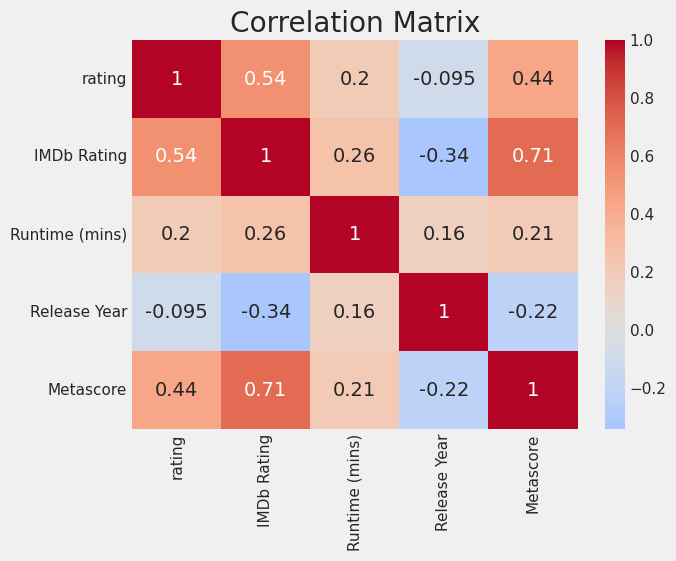

In [ ]:
corr_matrix = df_num.corr(numeric_only = True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

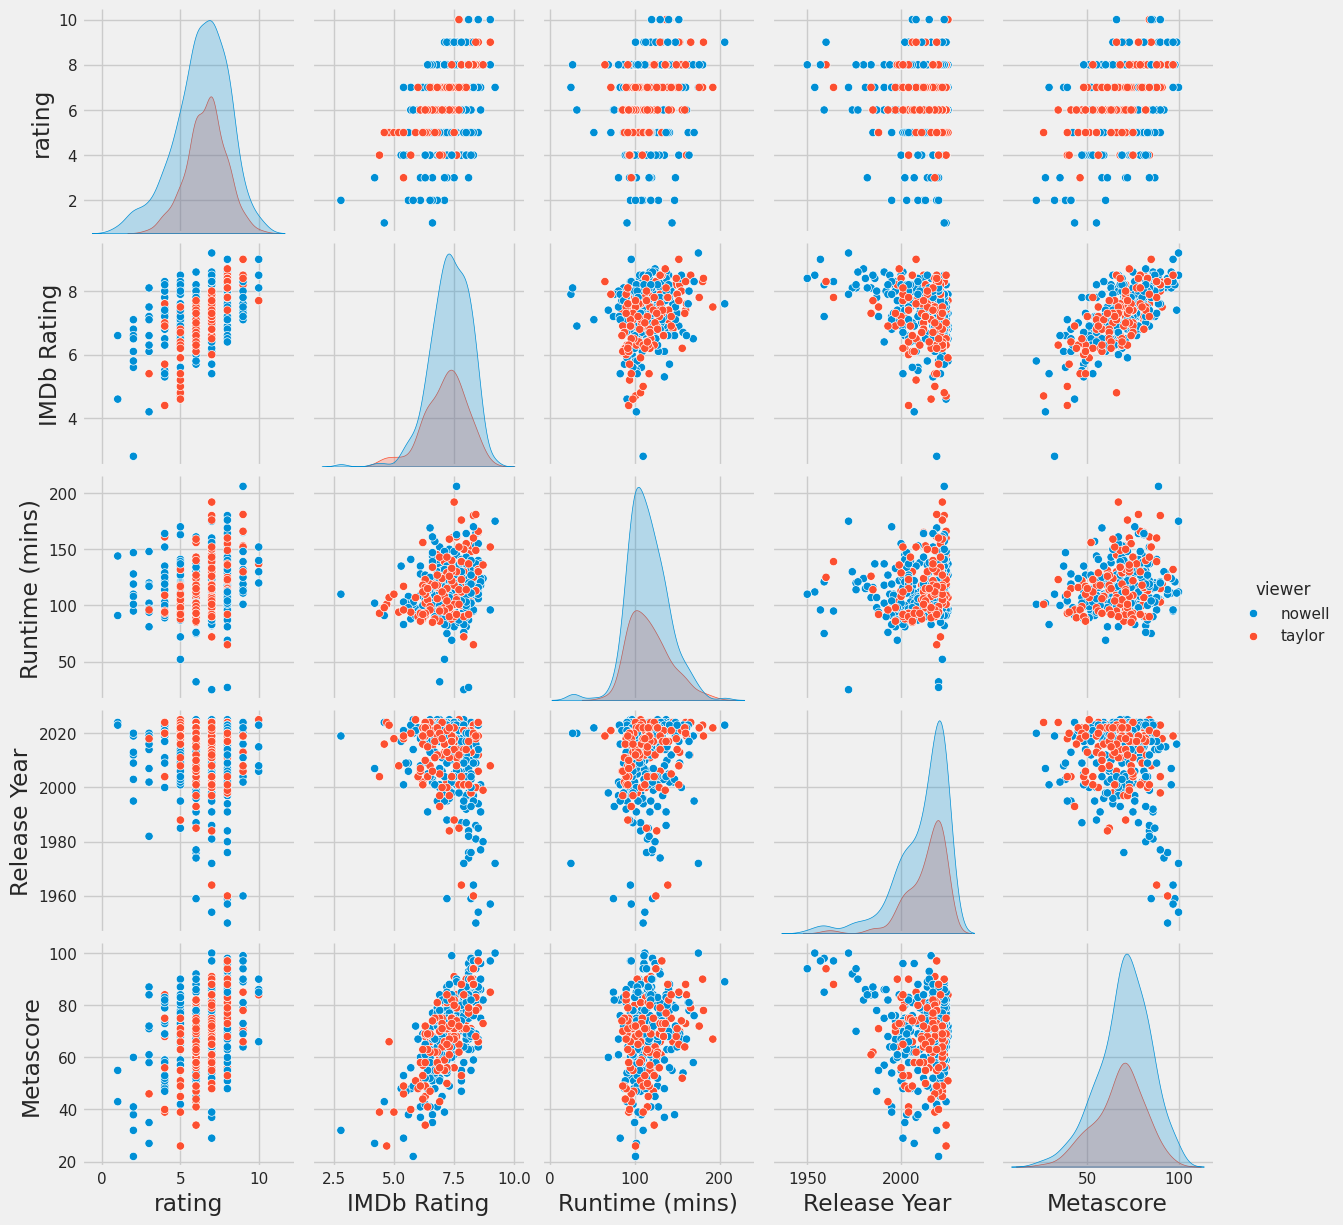

In [ ]:
sns.pairplot(df, hue='viewer')

<Axes: xlabel='Title Type', ylabel='count'>

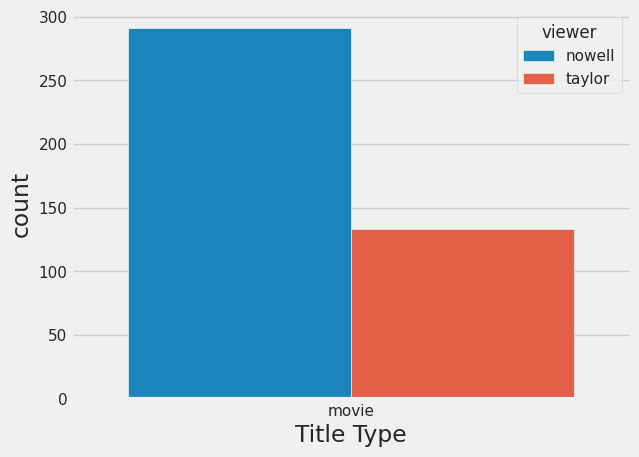

In [ ]:
sns.countplot(df, x='Title Type', hue='viewer')

## Data Cleaning


### Data Types

In [ ]:
# Remove Series and games as only looking at movies now
display(df['Title Type'].unique())
df = df[df['Title Type']=='movie']

array(['movie'], dtype=object)

In [ ]:
# Changing types to datatime
df['Date Rated']= pd.to_datetime(df['Date Rated'])
df['Release Date']= pd.to_datetime(df['Release Date'])
df['Release Year']= pd.to_datetime(df['Release Year'], format='%Y')
df['Release Year'] = df['Release Year'].dt.year
df['Runtime (mins)'] = pd.to_numeric(df['Runtime (mins)'], errors='coerce').astype('Int64')

In [ ]:
# Changing numerics to int
df['Num Votes'] = df['Num Votes'].str.replace(',', '').astype(int)
df['Box Office'] = df['Box Office'].str.replace(',', '').str.replace('$', '').astype(float)
display(df.dtypes)
display(df.info())

,0
ids.imdb,object
viewer,object
rating,int64
Date Rated,"datetime64[ns, UTC]"
Title,object
URL,object
Title Type,object
IMDb Rating,float64
Runtime (mins),Int64
Release Year,int32


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   ids.imdb        424 non-null    object             
 1   viewer          424 non-null    object             
 2   rating          424 non-null    int64              
 3   Date Rated      424 non-null    datetime64[ns, UTC]
 4   Title           424 non-null    object             
 5   URL             424 non-null    object             
 6   Title Type      424 non-null    object             
 7   IMDb Rating     424 non-null    float64            
 8   Runtime (mins)  423 non-null    Int64              
 9   Release Year    424 non-null    int32              
 10  Genres          424 non-null    object             
 11  Num Votes       424 non-null    int64              
 12  Release Date    424 non-null    datetime64[ns]     
 13  Directors       424 non-null    obj

None

### Columns Structure

In [ ]:
# Standardise columns
df.drop(columns=['Title Type'], inplace = True)
df.columns = [col.title() for col in df.columns]
df.rename(columns={'Rating':'User Rating','Imdb Rating': 'IMDb Rating', 'Ids.Imdb':'ids.imdb'}, inplace=True)
df.columns

Index(['ids.imdb', 'Viewer', 'User Rating', 'Date Rated', 'Title', 'Url',
       'IMDb Rating', 'Runtime (Mins)', 'Release Year', 'Genres', 'Num Votes',
       'Release Date', 'Directors', 'Actors', 'Language', 'Country', 'Awards',
       'Metascore', 'Box Office'],
      dtype='object')

### Duplicate and Null Values

In [ ]:
print("Duplicates", df.duplicated().sum())
print("Nulls\n", df.isnull().sum())

Duplicates 0
Nulls
 ids.imdb           0
Viewer             0
User Rating        0
Date Rated         0
Title              0
Url                0
IMDb Rating        0
Runtime (Mins)     1
Release Year       0
Genres             0
Num Votes          0
Release Date       0
Directors          0
Actors             0
Language           0
Country            1
Awards            12
Metascore         17
Box Office        48
dtype: int64


In [ ]:
# df.loc[df['Directors'].isna(),]
# df.loc[df['Directors'].isna(), ['Title', 'Release Year', 'Genres']].head(20)
# df.loc[df['Directors'].isna(), 'Viewer'].value_counts()
# df.loc[df['Directors'].isna(), 'Release Year'].value_counts().sort_index().plot()
# df.loc[df['Directors'].isna(), 'IMDb Rating'].describe()

In [ ]:
# misc =df.loc[df['Runtime (Mins)'].isna()]
# df.drop(misc.index, inplace=True)
df.drop(df.loc[df['Runtime (Mins)'].isna()].index, inplace=True)

## Data Preparation

#### Create new engineered features

#### Date

In [ ]:
# Movie release details
df['Release Decade'] = df['Release Year'] - (df['Release Year'] % 10)
df['Release Season'] = df['Release Date'].dt.quarter
df['Release Month'] = df['Release Date'].dt.month
df['Release Day'] = df['Release Date'].dt.day
df['Release Day of Week'] = df['Release Date'].dt.dayofweek
df.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker","Tate Donovan, Susan Egan, ...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,"Chris Appelhans, Maggie Kang","Arden Cho, May Hong, Ji-yo...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4
3,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"Short, Drama, Sci-Fi",21920,2020-11-20,"Travon Free, Martin Desmon...","Joey Bada$$, Zaria, Vincen...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"Comedy, Drama",69765,2014-12-30,Ruben Östlund,"Johannes Kuhnke, Lisa Love...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1
5,tt32221196,nowell,7,2025-06-11 23:26:44+00:00,One of Them Days,https://www.imdb.com/title...,6.50,97,2025,Comedy,14129,2025-01-17,Lawrence Lamont,"Keke Palmer, SZA, Vanessa ...",English,United States,NaN,71.00,50054690.00,2020,1,1,17,4


In [ ]:
df['Year Rated'] = df.loc[:,'Date Rated'].dt.year.copy()
df['Month Rated'] = df['Date Rated'].dt.month
df['Season Rated'] = df['Date Rated'].dt.quarter
df['Day Rated'] = df['Date Rated'].dt.day
df['Day of Week Rated'] = df['Date Rated'].dt.dayofweek
df.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker","Tate Donovan, Susan Egan, ...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,"Chris Appelhans, Maggie Kang","Arden Cho, May Hong, Ji-yo...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1
3,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"Short, Drama, Sci-Fi",21920,2020-11-20,"Travon Free, Martin Desmon...","Joey Bada$$, Zaria, Vincen...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"Comedy, Drama",69765,2014-12-30,Ruben Östlund,"Johannes Kuhnke, Lisa Love...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6
5,tt32221196,nowell,7,2025-06-11 23:26:44+00:00,One of Them Days,https://www.imdb.com/title...,6.50,97,2025,Comedy,14129,2025-01-17,Lawrence Lamont,"Keke Palmer, SZA, Vanessa ...",English,United States,NaN,71.00,50054690.00,2020,1,1,17,4,2025,6,2,11,2


#### Misc features

In [ ]:
# Log reviews for graphing
df['Log Votes'] = np.log(df['Num Votes'])
df['Log Votes'].describe()

,Log Votes
count,423.00
mean,12.40
std,1.32
min,6.21
25%,11.82
50%,12.63
75%,13.30
max,14.93


In [ ]:
df['Box Office Millions'] = df['Box Office'] / 1_000_000
df['Num Votes Thousands'] = df['Num Votes'] / 1_000
display(df['Box Office Millions'].describe())
display(df['Num Votes Thousands'].describe())

,Box Office Millions
count,376.00
mean,141.77
std,156.77
min,0.01
25%,34.50
50%,94.45
75%,183.65
max,936.66


,Num Votes Thousands
count,423.00
mean,440.45
std,447.10
min,0.50
25%,136.56
50%,305.73
75%,595.96
max,3044.55


In [ ]:
taylor = df['Viewer']=='taylor'
nowell = df['Viewer']=='nowell'

In [ ]:
# Rounded IMDb ratings for comparison
df['IMDb Rating Rounded'] = df.loc[:,'IMDb Rating'].round()

In [ ]:
rating_bins = [0, 5.9, 7.9, 10]
rating_labels = ['Low', 'Medium', 'High']
df['Rating_Category'] = pd.cut(df['IMDb Rating'], bins=rating_bins, labels=rating_labels, include_lowest=True)

In [ ]:
df['Primary Genre'] = df['Genres'].str.split(',').str[0]
display(df['Primary Genre'].value_counts())

,count
Primary Genre,
Action,147
Animation,77
Comedy,77
Drama,45
Crime,25
Adventure,18
Biography,15
Horror,12
Short,2


#### Exploding list columns

In [ ]:
df['Actors'] = df['Actors'].fillna('').apply(lambda x: [actor.strip() for actor in x.split(',')])

df_actors = df.explode('Actors').reset_index(drop=True)
df_actors.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker",Tate Donovan,"English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
1,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker",Susan Egan,"English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
2,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker",James Woods,"English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
3,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,"Chris Appelhans, Maggie Kang",Arden Cho,"English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,7.44,NaN,1.71,8.00,Medium,Animation
4,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,"Chris Appelhans, Maggie Kang",May Hong,"English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,7.44,NaN,1.71,8.00,Medium,Animation


In [ ]:
# Remove spaces and split by comma
df['Directors'] = df['Directors'].fillna('').apply(lambda x: [director.strip() for director in x.split(',')])
# Exploding directors
df_directors = df.explode('Directors').reset_index(drop=True)
df_directors.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,Ron Clements,"[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
1,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,John Musker,"[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
2,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,Chris Appelhans,"[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,7.44,NaN,1.71,8.00,Medium,Animation
3,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,Maggie Kang,"[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,7.44,NaN,1.71,8.00,Medium,Animation
4,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"Short, Drama, Sci-Fi",21920,2020-11-20,Travon Free,"[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,10.00,NaN,21.92,7.00,Medium,Short


Exploding genres

In [ ]:
# Remove spaces and split by comma
df['Genres'] = df['Genres'].fillna('').apply(lambda x: [genre.strip() for genre in x.split(',')])
df.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"[Animation, Action, Advent...",268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"[Animation, Action, Advent...",1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,7.44,NaN,1.71,8.00,Medium,Animation
3,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"[Short, Drama, Sci-Fi]",21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,10.00,NaN,21.92,7.00,Medium,Short
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"[Comedy, Drama]",69765,2014-12-30,[Ruben Östlund],"[Johannes Kuhnke, Lisa Lov...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6,11.15,1.36,69.77,7.00,Medium,Comedy
5,tt32221196,nowell,7,2025-06-11 23:26:44+00:00,One of Them Days,https://www.imdb.com/title...,6.50,97,2025,[Comedy],14129,2025-01-17,[Lawrence Lamont],"[Keke Palmer, SZA, Vanessa...",English,United States,NaN,71.00,50054690.00,2020,1,1,17,4,2025,6,2,11,2,9.56,50.05,14.13,6.00,Medium,Comedy


In [ ]:
# Explode genres
df_genres = df.explode('Genres').reset_index(drop=True)
df_genres.head(10)

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,Animation,268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
1,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,Action,268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
2,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,Adventure,268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
3,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,Animation,1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,7.44,NaN,1.71,8.00,Medium,Animation
4,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,Action,1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,7.44,NaN,1.71,8.00,Medium,Animation
5,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,Adventure,1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,7.44,NaN,1.71,8.00,Medium,Animation
6,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,Short,21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,10.00,NaN,21.92,7.00,Medium,Short
7,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,Drama,21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,10.00,NaN,21.92,7.00,Medium,Short
8,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,Sci-Fi,21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,10.00,NaN,21.92,7.00,Medium,Short
9,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,Comedy,69765,2014-12-30,[Ruben Östlund],"[Johannes Kuhnke, Lisa Lov...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6,11.15,1.36,69.77,7.00,Medium,Comedy


In [ ]:
df['Country'] = df['Country'].fillna('').apply(lambda x: [country.strip() for country in x.split(',')])
df_country = df.explode('Country').reset_index(drop=True)
df_country.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"[Animation, Action, Advent...",268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,12.50,99.11,268.26,7.00,Medium,Animation
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"[Animation, Action, Advent...",1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,7.44,NaN,1.71,8.00,Medium,Animation
2,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"[Short, Drama, Sci-Fi]",21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,10.00,NaN,21.92,7.00,Medium,Short
3,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"[Comedy, Drama]",69765,2014-12-30,[Ruben Östlund],"[Johannes Kuhnke, Lisa Lov...","Swedish, Norwegian, Englis...",Sweden,Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6,11.15,1.36,69.77,7.00,Medium,Comedy
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"[Comedy, Drama]",69765,2014-12-30,[Ruben Östlund],"[Johannes Kuhnke, Lisa Lov...","Swedish, Norwegian, Englis...",France,Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6,11.15,1.36,69.77,7.00,Medium,Comedy


### Final Validation

In [ ]:
# Reorder columns
cols = df.columns

first = ['Title', 'IMDb Rating', 'User Rating', 'Viewer',
       'Release Date', 'Date Rated',
       'Box Office Millions', 'Num Votes Thousands', 'Runtime (Mins)',
       'Country', 'Awards', 'Metascore', 'Primary Genre',
       'Directors', 'Actors', 'Language']
# first = [cols[3], cols[5], cols[9], cols[6], cols[1], cols[11],cols[2]]
remaining = [col for col in cols if col not in first]

cols = first + remaining
df = df[cols]
df.columns

Index(['Title', 'IMDb Rating', 'User Rating', 'Viewer', 'Release Date',
       'Date Rated', 'Box Office Millions', 'Num Votes Thousands',
       'Runtime (Mins)', 'Country', 'Awards', 'Metascore', 'Primary Genre',
       'Directors', 'Actors', 'Language', 'ids.imdb', 'Url', 'Release Year',
       'Genres', 'Num Votes', 'Box Office', 'Release Decade', 'Release Season',
       'Release Month', 'Release Day', 'Release Day of Week', 'Year Rated',
       'Month Rated', 'Season Rated', 'Day Rated', 'Day of Week Rated',
       'Log Votes', 'IMDb Rating Rounded', 'Rating_Category'],
      dtype='object')

In [ ]:
display(df.info())
display(df_genres.info())
display(df_directors.info())
display(df_actors.info())
display(df_country.info())

<class 'pandas.core.frame.DataFrame'>
Index: 423 entries, 0 to 423
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   Title                423 non-null    object             
 1   IMDb Rating          423 non-null    float64            
 2   User Rating          423 non-null    int64              
 3   Viewer               423 non-null    object             
 4   Release Date         423 non-null    datetime64[ns]     
 5   Date Rated           423 non-null    datetime64[ns, UTC]
 6   Box Office Millions  376 non-null    float64            
 7   Num Votes Thousands  423 non-null    float64            
 8   Runtime (Mins)       423 non-null    Int64              
 9   Country              423 non-null    object             
 10  Awards               412 non-null    object             
 11  Metascore            407 non-null    float64            
 12  Primary Genre        423 no

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ids.imdb             1184 non-null   object             
 1   Viewer               1184 non-null   object             
 2   User Rating          1184 non-null   int64              
 3   Date Rated           1184 non-null   datetime64[ns, UTC]
 4   Title                1184 non-null   object             
 5   Url                  1184 non-null   object             
 6   IMDb Rating          1184 non-null   float64            
 7   Runtime (Mins)       1184 non-null   Int64              
 8   Release Year         1184 non-null   int32              
 9   Genres               1184 non-null   object             
 10  Num Votes            1184 non-null   int64              
 11  Release Date         1184 non-null   datetime64[ns]     
 12  Directors           

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ids.imdb             507 non-null    object             
 1   Viewer               507 non-null    object             
 2   User Rating          507 non-null    int64              
 3   Date Rated           507 non-null    datetime64[ns, UTC]
 4   Title                507 non-null    object             
 5   Url                  507 non-null    object             
 6   IMDb Rating          507 non-null    float64            
 7   Runtime (Mins)       507 non-null    Int64              
 8   Release Year         507 non-null    int32              
 9   Genres               507 non-null    object             
 10  Num Votes            507 non-null    int64              
 11  Release Date         507 non-null    datetime64[ns]     
 12  Directors            5

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1264 entries, 0 to 1263
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ids.imdb             1264 non-null   object             
 1   Viewer               1264 non-null   object             
 2   User Rating          1264 non-null   int64              
 3   Date Rated           1264 non-null   datetime64[ns, UTC]
 4   Title                1264 non-null   object             
 5   Url                  1264 non-null   object             
 6   IMDb Rating          1264 non-null   float64            
 7   Runtime (Mins)       1264 non-null   Int64              
 8   Release Year         1264 non-null   int32              
 9   Genres               1264 non-null   object             
 10  Num Votes            1264 non-null   int64              
 11  Release Date         1264 non-null   datetime64[ns]     
 12  Directors           

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776 entries, 0 to 775
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ids.imdb             776 non-null    object             
 1   Viewer               776 non-null    object             
 2   User Rating          776 non-null    int64              
 3   Date Rated           776 non-null    datetime64[ns, UTC]
 4   Title                776 non-null    object             
 5   Url                  776 non-null    object             
 6   IMDb Rating          776 non-null    float64            
 7   Runtime (Mins)       776 non-null    Int64              
 8   Release Year         776 non-null    int32              
 9   Genres               776 non-null    object             
 10  Num Votes            776 non-null    int64              
 11  Release Date         776 non-null    datetime64[ns]     
 12  Directors            7

None

In [ ]:
# Save clean dataset
df.to_parquet('cleaned_enriched_movies.parquet', index=False)
df_genres.to_parquet('cleaned_enriched_movies_genres.parquet', index=False)
df_directors.to_parquet('cleaned_enriched_movies_directors.parquet', index=False)
df_actors.to_parquet('cleaned_enriched_movies_actors.parquet', index=False)
df_country.to_parquet('cleaned_enriched_movies_country.parquet', index=False)